Exception ignored in: <function NpzFile.__del__ at 0x7d47d0b59e40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


Mounted at /content/drive
Loading data and model...


Total classes in dataset: 38
Classes present in test set: 6
Test class indices: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37)]
Test class names: [np.str_('Tomato___Septoria_leaf_spot'), np.str_('Tomato___Spider_mites Two-spotted_spider_mite'), np.str_('Tomato___Target_Spot'), np.str_('Tomato___Tomato_Yellow_Leaf_Curl_Virus'), np.str_('Tomato___Tomato_mosaic_virus'), np.str_('Tomato___healthy')]

Loading model...

Generating predictions...
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
340/340 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
All predicted classes: [np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37)]

CLASSIFICATION REPORT (common classes only):
                                               precision    recall  f1-score   support

                  Tomato___Septoria_leaf_spot     0.9829    1.0000    0.9914       460
Tomato___Spider_mites Two-spotted_spider_mite     0.

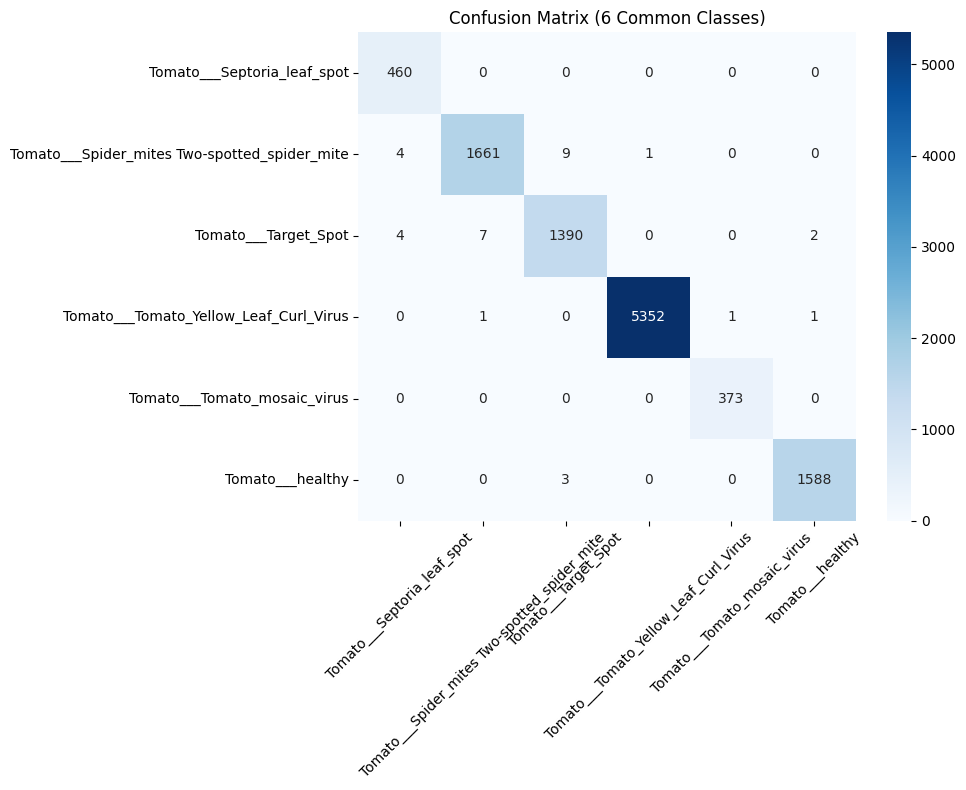


Performing error analysis...
Total Errors: 37 (0.34%)

TOP ERROR TYPES:
True Class Name
Tomato___Spider_mites Two-spotted_spider_mite    15
Tomato___Target_Spot                             14
Tomato___Tomato_Yellow_Leaf_Curl_Virus            5
Tomato___healthy                                  3
Name: count, dtype: int64

HIGH CONFIDENCE ERRORS (Pred Prob > 0.7):
    True Class  Predicted Class  \
23          34               32   
19          34               33   
25          34               33   
10          33               34   
36          37               34   
4           33               34   
2           33               34   
22          34               37   
26          34               37   
12          33               34   

                                  True Class Name  \
23                           Tomato___Target_Spot   
19                           Tomato___Target_Spot   
25                           Tomato___Target_Spot   
10  Tomato___Spider_mites Two-spotte

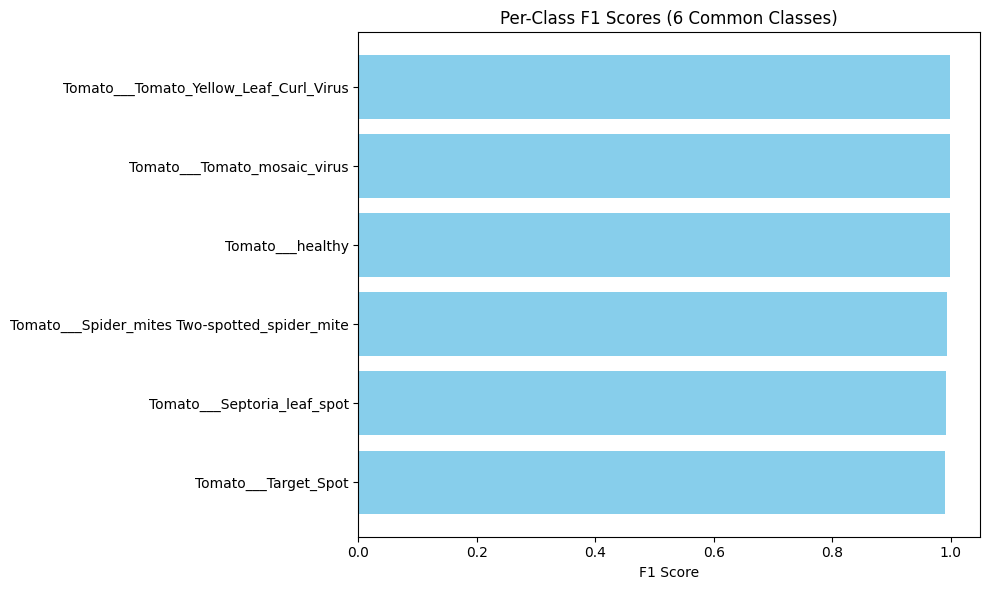


Saving analysis results...

Analysis complete! Saved to Google Drive:
- tiny_nn_detailed_metrics_common.csv
- tiny_nn_error_analysis_common.csv
- tiny_nn_f1_common.png
- tiny_nn_confusion_common.png

Full analysis of all predictions vs test classes:

Classes predicted but not in test set: [np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
These classes were predicted but don't appear in your test set:
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Leaf_Mold

All test classes were predicted at least once
   - Accuracy: 99.66%
   - Error rate: 0.34%


In [8]:
"""
# Tiny NN Final Evaluation
Correctly handles the case where test set has fewer classes than model can predict
"""

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load data and model
print("Loading data and model...")
data = np.load("/content/drive/MyDrive/PlantVillage_Project/data/processed/efficientnetv2_features.npz")
X_test = data['features'][43444:]  # Last 20% as test
y_test = np.argmax(data['labels'], axis=1)[43444:]
all_class_names = data['class_names']  # All 38 class names

# Get actual classes present in test set
test_classes = np.unique(y_test)
class_names = [all_class_names[i] for i in sorted(test_classes)]
num_test_classes = len(test_classes)

print(f"Total classes in dataset: {len(all_class_names)}")
print(f"Classes present in test set: {num_test_classes}")
print(f"Test class indices: {sorted(test_classes)}")
print(f"Test class names: {class_names}")

# Load model
print("\nLoading model...")
model = tf.keras.models.load_model('/content/drive/MyDrive/PlantVillage_Project/models/tiny_nn_best.h5')

# Generate predictions
print("\nGenerating predictions...")
y_pred = np.argmax(model.predict(X_test), axis=1)
y_prob = model.predict(X_test)

# Get all predicted classes (some may not be in test set)
all_predicted_classes = np.unique(np.concatenate((y_test, y_pred)))
print(f"All predicted classes: {sorted(all_predicted_classes)}")

# 1. Classification Report - use only classes that appear in BOTH test and predictions
common_classes = np.intersect1d(y_test, y_pred)
common_class_names = [all_class_names[i] for i in sorted(common_classes)]

print("\nCLASSIFICATION REPORT (common classes only):")
print(classification_report(
    y_test,
    y_pred,
    labels=common_classes,
    target_names=common_class_names,
    digits=4,
    zero_division=0
))

# 2. Confusion Matrix (only for common classes)
print("\nGenerating confusion matrix for common classes...")
cm = confusion_matrix(y_test, y_pred, labels=common_classes)

# Create DataFrame with common classes
cm_df = pd.DataFrame(cm,
                    index=common_class_names,
                    columns=common_class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix ({len(common_classes)} Common Classes)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PlantVillage_Project/tiny_nn_confusion_common.png')
plt.show()

# 3. Error Analysis
print("\nPerforming error analysis...")
errors = np.where(y_pred != y_test)[0]
error_rate = len(errors)/len(y_test)
print(f"Total Errors: {len(errors)} ({error_rate:.2%})")

# Create error dataframe
error_df = pd.DataFrame({
    'True Class': y_test[errors],
    'Predicted Class': y_pred[errors],
    'True Class Name': [all_class_names[i] for i in y_test[errors]],
    'Predicted Class Name': [all_class_names[i] for i in y_pred[errors]],
    'True Probability': [y_prob[errors[i], y_test[errors[i]]] for i in range(len(errors))],
    'Predicted Probability': [y_prob[errors[i], y_pred[errors[i]]] for i in range(len(errors))]
})

# Show most common errors
print("\nTOP ERROR TYPES:")
print(error_df['True Class Name'].value_counts().head(10))

# Show highest confidence errors
high_conf_errors = error_df[error_df['Predicted Probability'] > 0.7]
if len(high_conf_errors) > 0:
    print("\nHIGH CONFIDENCE ERRORS (Pred Prob > 0.7):")
    print(high_conf_errors.sort_values('Predicted Probability', ascending=False).head(10))
else:
    print("\nNo high-confidence errors found")

# 4. Per-Class Metrics (only for common classes)
print("\nCalculating per-class metrics for common classes...")
class_metrics = []
for i in common_classes:
    # Get true index in the confusion matrix
    matrix_idx = np.where(common_classes == i)[0][0]
    tp = cm[matrix_idx, matrix_idx]
    fp = cm[:, matrix_idx].sum() - tp
    fn = cm[matrix_idx, :].sum() - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    class_metrics.append({
        'Class': all_class_names[i],
        'Support': cm[matrix_idx, :].sum(),
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Errors': cm[matrix_idx, :].sum() - tp
    })

metrics_df = pd.DataFrame(class_metrics).sort_values('F1', ascending=False)

# 5. Visualize Class Performance
print("\nVisualizing class performance for common classes...")
plt.figure(figsize=(10, 6))
plt.barh(metrics_df['Class'], metrics_df['F1'], color='skyblue')
plt.title(f'Per-Class F1 Scores ({len(common_classes)} Common Classes)')
plt.xlabel('F1 Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PlantVillage_Project/tiny_nn_f1_common.png')
plt.show()

# 6. Save Full Analysis
print("\nSaving analysis results...")
metrics_df.to_csv('/content/drive/MyDrive/PlantVillage_Project/tiny_nn_detailed_metrics_common.csv', index=False)
error_df.to_csv('/content/drive/MyDrive/PlantVillage_Project/tiny_nn_error_analysis_common.csv', index=False)

print("\nAnalysis complete! Saved to Google Drive:")
print("- tiny_nn_detailed_metrics_common.csv")
print("- tiny_nn_error_analysis_common.csv")
print("- tiny_nn_f1_common.png")
print("- tiny_nn_confusion_common.png")

# 7. Full Analysis of All Predictions
print("\nFull analysis of all predictions vs test classes:")

# Classes predicted but not in test set
predicted_not_in_test = np.setdiff1d(y_pred, y_test)
if len(predicted_not_in_test) > 0:
    print(f"\nClasses predicted but not in test set: {sorted(predicted_not_in_test)}")
    print("These classes were predicted but don't appear in your test set:")
    for cls in sorted(predicted_not_in_test):
        print(f"- {all_class_names[cls]}")
else:
    print("\nAll predicted classes were present in test set")

# Classes in test set but not predicted
test_not_predicted = np.setdiff1d(y_test, y_pred)
if len(test_not_predicted) > 0:
    print(f"\nClasses in test set but never predicted: {sorted(test_not_predicted)}")
    print("These classes appear in your test set but were never predicted:")
    for cls in sorted(test_not_predicted):
        print(f"- {all_class_names[cls]}")
else:
    print("\nAll test classes were predicted at least once")

print(f"   - Accuracy: {np.mean(y_pred == y_test):.2%}")
print(f"   - Error rate: {error_rate:.2%}")